# Анализ качества работы нейронной сети для распознавания моделей одежды в Keras

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

## Подготовка данных для обучения сети

**Загружаем набор данных**

In [ ]:
# В Keras встроены средства работы с популярными наборами данных
# (x_train, y_train) - набор данных для обучения
# (x_test, y_test) - набор данных для тестирования
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Список с названиями классов

In [ ]:
classes = ['футболка', 'брюки', 'свитер', 'платье', 'пальто', 'туфли', 'рубашка', 'кроссовки', 'сумка', 'ботинки']

Просматриваем примеры изображений

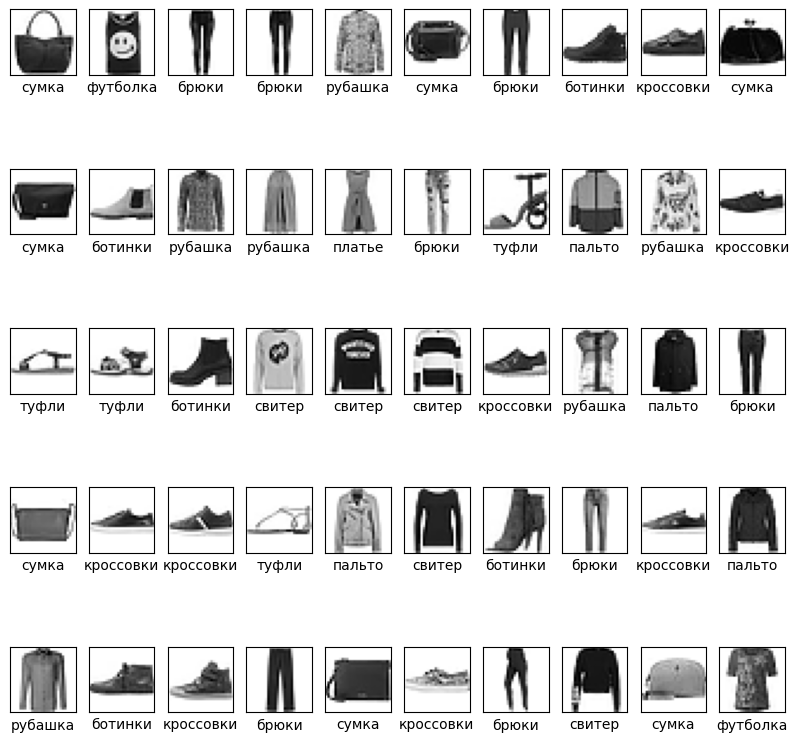

In [ ]:
plt.figure(figsize=(10,10))
for i in range(100,150):
    plt.subplot(5,10,i-100+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(classes[y_train[i]])

**Преобразование размерности данных в наборе**

In [ ]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

**Нормализация данных**

In [ ]:
# Векторизованные операции
# Применяются к каждому элементу массива отдельно
x_train = x_train / 255
x_test = x_test / 255

**Работа с правильными ответами**

In [ ]:
n = 0

In [ ]:
print(y_train[n])

9


**Преобразуем метки в формат one hot encoding**

In [ ]:
y_train = utils.to_categorical(y_train, 10)

In [ ]:
y_test = utils.to_categorical(y_test, 10)

**Правильный ответ в формате one hot encoding**

In [ ]:
print(y_train[n])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## Создаем нейронную сеть

**Создаем последовательную модель**

In [ ]:
histories = []

def create_and_train(name, X_train, y_train, layers=[800], batch_size=200, epochs=20, activator="relu", optimizer="Adam", verbose=1):
  if verbose:
    print(f"Creating model: {name}")

  model = Sequential()
  model.add(Dense(layers[0], input_dim=784, activation=activator))

  for neurons in layers[1:]:
        model.add(Dense(neurons, activation=activator))

  model.add(Dense(10, activation="softmax"))

  model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

  if verbose:
    print(f"Learning model: {name}")

  history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2, verbose=0)

  if verbose:
    print(f"Model {name} learned")

  return history.history, model



In [ ]:
history, model = create_and_train('Example', x_train, y_train, verbose = 1) # Model from example
histories.append({"Example": history})
print(histories)

Creating model: Example
Learning model: Example
Model Example learned
[{'Example': {'accuracy': [0.809374988079071, 0.8621666431427002, 0.875166654586792, 0.8854583501815796, 0.8921041488647461, 0.8965833187103271, 0.9039999842643738, 0.9087291955947876, 0.9116458296775818, 0.9150624871253967, 0.9191874861717224, 0.9201250076293945, 0.9264166951179504, 0.9269791841506958, 0.9289791584014893, 0.9343125224113464, 0.9356041550636292, 0.9394583106040955, 0.9394583106040955, 0.9430208206176758], 'loss': [0.5458075404167175, 0.39016109704971313, 0.3432998061180115, 0.3180469870567322, 0.29558929800987244, 0.2789403200149536, 0.2609521746635437, 0.24982668459415436, 0.239007368683815, 0.22982653975486755, 0.22065912187099457, 0.21598541736602783, 0.2017902433872223, 0.19773714244365692, 0.19244998693466187, 0.18196043372154236, 0.17356517910957336, 0.16873858869075775, 0.16508542001247406, 0.15745341777801514], 'val_accuracy': [0.8512499928474426, 0.871999979019165, 0.8680833578109741, 0.8698

In [ ]:
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 800)            │       628,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,908,032 (7.28 MB)

 Trainable params: 636,010 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,272,022 (4.85 MB)

None


# Рубрика ээээксперименты

Проведём эксперимент: обучим несколько моделей с различными гиперпараметрами - один изменяем, остальные фиксированные

In [ ]:
model_groups = {
    'neurons_layers_comparation' : {
        'base' : {'batch_size' : 200, 'epochs' : 20, 'optimizer' : 'Adam'},
        'var' : {
            'neurons_layer_400' : {'layers' : [400]},
            'neurons_layer_600' : {'layers' : [600]},
            'neurons_layer_800' : {'layers' : [800]},
            'neurons_layer_1200' : {'layers' : [1200]}
        }
    },

    'hidden_layers_comparation' : {
        'base' : {'batch_size' : 200, 'epochs' : 20, 'optimizer' : 'Adam'},
        'var' : {
            '1_layer' : {'layers' : [800]},
            '2_layers' : {'layers' : [800, 200]},
            '3_layers' : {'layers' : [800, 300, 200]},
            '4_layers' : {'layers' : [800, 400, 300, 200]},
            '5_layers' : {'layers' : [800, 600, 400, 300, 200]}
        }
    },

    'epochs_comparation' : {
        'base' : {'batch_size' : 200, 'layers' : [800], 'optimizer' : 'Adam'},
        'var' : {
            '10_epochs' : {'epochs' : 10},
            '15_epochs' : {'epochs' : 15},
            '20_epochs' : {'epochs' : 20},
            '25_epochs' : {'epochs' : 25},
            '30_epochs' : {'epochs' : 30}
        }
    },

    'batch_size_comparation' : {
        'base' : {'epochs' : 20, 'layers' : [800], 'optimizer' : 'Adam'},
        'var' : {
            'batch_10' : {'batch_size' : 10},
            'batch_50' : {'batch_size' : 50},
            'batch_100' : {'batch_size' : 100},
            'batch_200' : {'batch_size' : 200},
            'batch_500' : {'batch_size' : 500}
        }
    },

    'optimizers_comparation' : {
        'base' : {'batch_size' : 200, 'epochs' : 20, 'layers' : [800]},
        'var' : {
            'Adam' : {'optimizer' : 'Adam'},
            'SGD' : {'optimizer' : 'SGD'},
            'RMSprop' : {'optimizer' : 'RMSprop'}
        }
    }
}


results = {}

for model_group_name, model_group_params in model_groups.items():
  print("="*100)
  print(f'Experimetnal group : {model_group_name}')
  print("="*100 + '\n')

  group_result = []
  base_params = model_group_params['base']

  for var_name, var_params in model_group_params['var'].items():
    params = {**base_params, **var_params}
    case_name = f'{model_group_name} - {var_name}'
    print('Started case: ' + case_name)
    print(f'Params: {params}')

    history, model = create_and_train(
        name=case_name,
        X_train=x_train,
        y_train=y_train,
        layers=params['layers'],
        batch_size=params['batch_size'],
        epochs=params['epochs'],
        optimizer=params['optimizer']
    )

    result = {
        'name': case_name,
        'history': history,
        'model': model,
        'params': params,
        'group': model_group_name
        }

    group_result.append(result)

    final_val_acc = history['val_accuracy'][-1]
    final_train_acc = history['accuracy'][-1]
    overfitting = final_train_acc - final_val_acc

    print(f"Fast rate: val_acc={final_val_acc:.4f}, overfitting={overfitting:.4f}\n\n")

  results[model_group_name] = group_result

print("="*100)
print('All experiments ended!')
print("="*100)


Experimetnal group : neurons_layers_comparation

Started case: neurons_layers_comparation - neurons_layer_400
Params: {'batch_size': 200, 'epochs': 20, 'optimizer': 'Adam', 'layers': [400]}
Creating model: neurons_layers_comparation - neurons_layer_400
Learning model: neurons_layers_comparation - neurons_layer_400
Model neurons_layers_comparation - neurons_layer_400 learned
Fast rate: val_acc=0.8974, overfitting=0.0384


Started case: neurons_layers_comparation - neurons_layer_600
Params: {'batch_size': 200, 'epochs': 20, 'optimizer': 'Adam', 'layers': [600]}
Creating model: neurons_layers_comparation - neurons_layer_600
Learning model: neurons_layers_comparation - neurons_layer_600
Model neurons_layers_comparation - neurons_layer_600 learned
Fast rate: val_acc=0.8942, overfitting=0.0453


Started case: neurons_layers_comparation - neurons_layer_800
Params: {'batch_size': 200, 'epochs': 20, 'optimizer': 'Adam', 'layers': [800]}
Creating model: neurons_layers_comparation - neurons_layer

# А сейчас будет анализ и графики

All groups analisys
Analyze group: neurons_layers_comparation
Модель                         Val Acc  Train Acc  Val Loss Train Loss Overfit  Параметры
neurons_layers_comparation     0.8983  0.9448    0.3145   0.1525     0.0464   Heuron layer: 1200
----------------------------------------------------------------------------------------------------
neurons_layers_comparation     0.8974  0.9359    0.3022   0.1703     0.0384   Heuron layer: 400
----------------------------------------------------------------------------------------------------
neurons_layers_comparation     0.8970  0.9403    0.3048   0.1616     0.0433   Heuron layer: 800
----------------------------------------------------------------------------------------------------
neurons_layers_comparation     0.8942  0.9395    0.3137   0.1655     0.0453   Heuron layer: 600
----------------------------------------------------------------------------------------------------
Analyze group: hidden_layers_comparation
Модель            

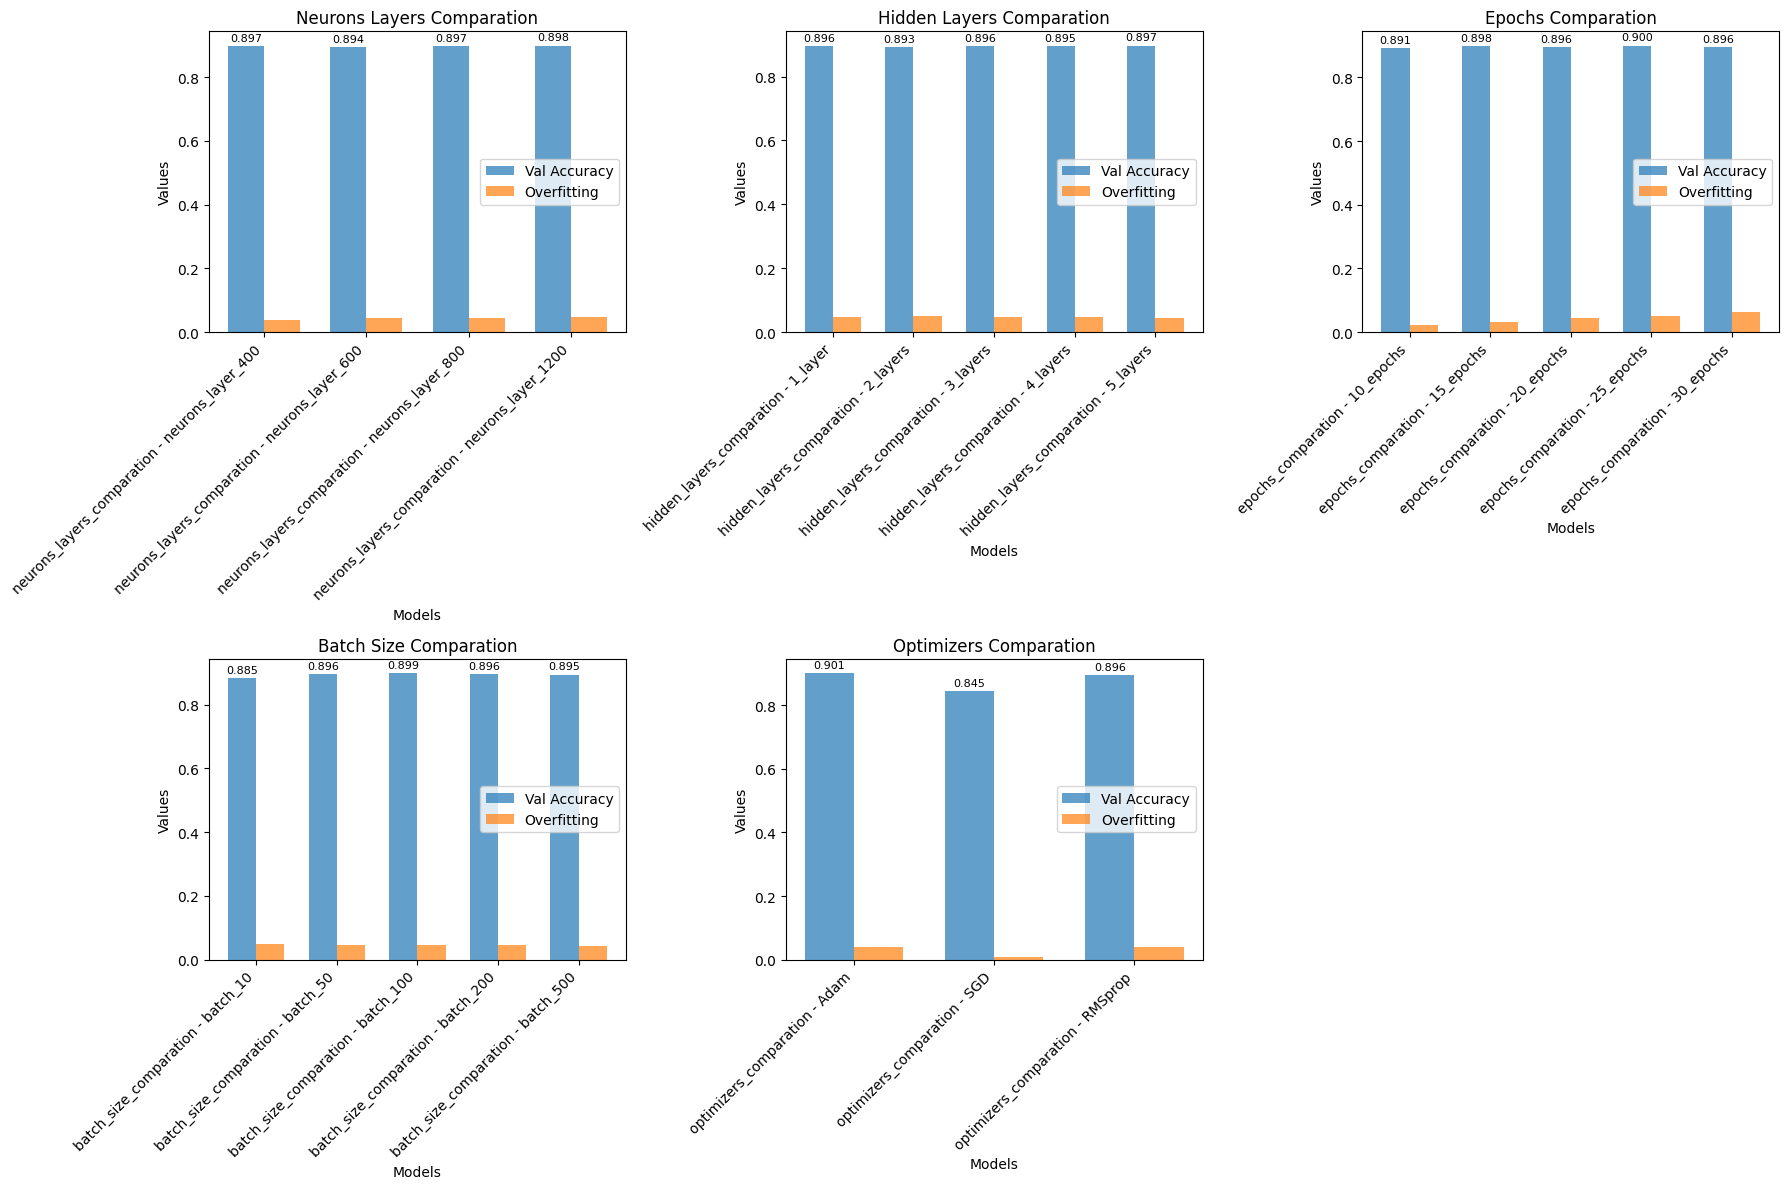

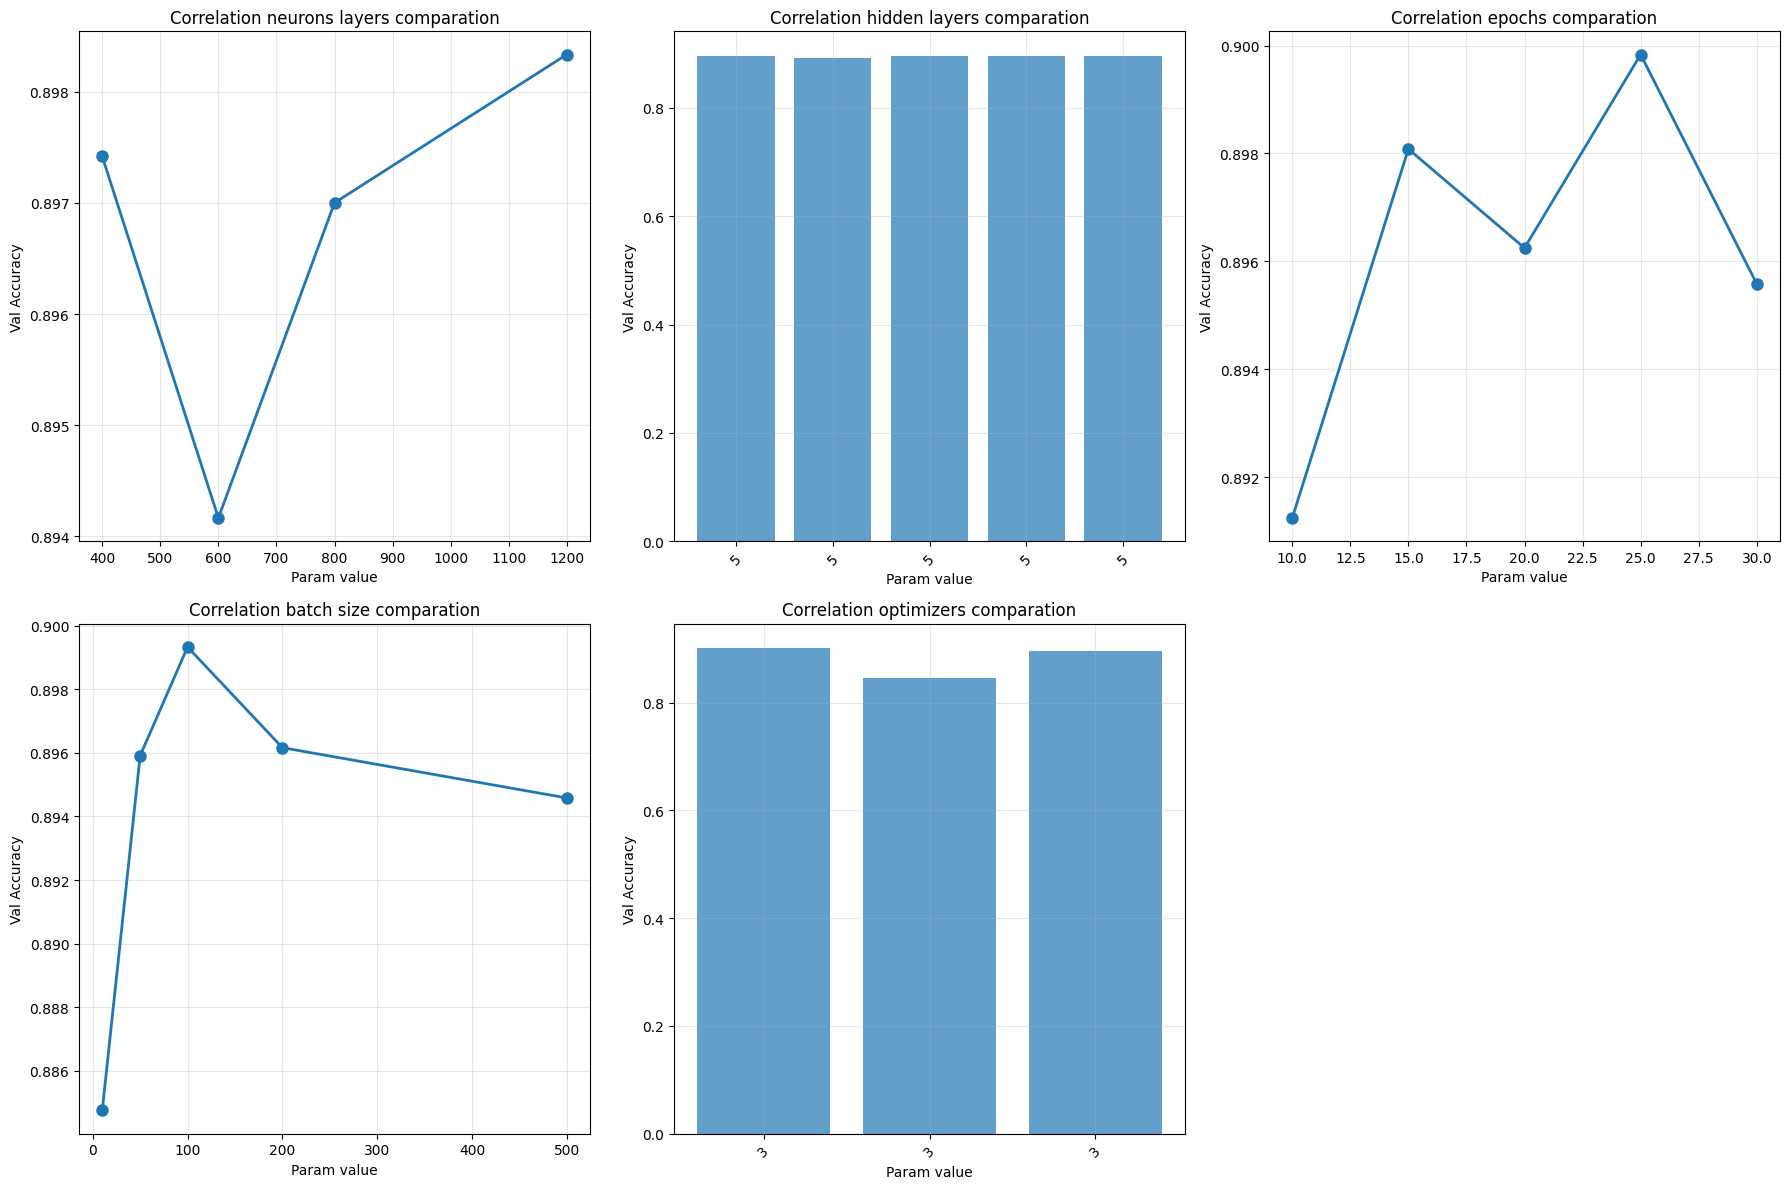

In [ ]:
def analyze_group(name, group_results):
  print('=' * 100)
  print(f'Analyze group: {name}')
  print('=' * 100)

  sorted_results = sorted(group_results, key=lambda x: x['history']['val_accuracy'][-1], reverse=True)

  print(f"{'Модель':<30} {'Val Acc':<8} {'Train Acc':<10} {'Val Loss':<8} {'Train Loss':<10} {'Overfit':<8} {'Параметры'}")
  print("=" * 110)

  for result in sorted_results:
    history = result['history']
    params = result['params']

    val_acc = history['val_accuracy'][-1]
    train_acc = history['accuracy'][-1]
    val_loss = history['val_loss'][-1]
    train_loss = history['loss'][-1]
    overfitting = train_acc - val_acc

    if name == 'neurons_layers_comparation':
      param_desc = f"Heuron layer: {params['layers'][0]}"
    elif name == 'hidden_layers_comparation':
      layers_str = '-'.join(map(str, params['layers']))
      param_desc = f"Layers: {layers_str}"
    elif name == 'epochs_comparation':
      param_desc = f"Epochs: {params['epochs']}"
    elif name == 'batch_size_comparation':
      param_desc = f"Batch: {params['batch_size']}"
    elif name == 'optimizer_comparation':
      param_desc = f"Optim: {params['optimizer']}"
    else:
      param_desc = str(params)

    print(f"{name:<30} {val_acc:.4f}  {train_acc:.4f}    {val_loss:.4f}   {train_loss:.4f}     {overfitting:.4f}   {param_desc}")
    print('-' * 100)


def plot_group(groups_results):
  fig, axes = plt.subplots(2, 3, figsize=(18, 12))
  axes = axes.flatten()

  for i, (group_name, group_results) in enumerate(groups_results.items()):
      if i >= len(axes):
          break

      ax = axes[i]
      names = []
      val_accuracies = []
      overfitting_values = []

      for result in group_results:
          history = result['history']
          val_acc = history['val_accuracy'][-1]
          train_acc = history['accuracy'][-1]
          overfitting = train_acc - val_acc

          names.append(result['name'].replace(f"{group_name}_", ""))
          val_accuracies.append(val_acc)
          overfitting_values.append(overfitting)

      x = np.arange(len(names))
      width = 0.35

      bars1 = ax.bar(x - width/2, val_accuracies, width, label='Val Accuracy', alpha=0.7)
      bars2 = ax.bar(x + width/2, overfitting_values, width, label='Overfitting', alpha=0.7)

      ax.set_xlabel('Models')
      ax.set_ylabel('Values')
      ax.set_title(f'{group_name.replace("_", " ").title()}')
      ax.set_xticks(x)
      ax.set_xticklabels(names, rotation=45, ha='right')
      ax.legend()

      for bar, acc in zip(bars1, val_accuracies):
          ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=8)

  for j in range(i + 1, len(axes)):
      fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()


def plot_parameter_correlation(groups_results):

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, (group_name, group_results) in enumerate(groups_results.items()):
        if i >= len(axes):
            break

        ax = axes[i]

        x_values = []
        y_values = []

        for result in group_results:
            history = result['history']
            params = result['params']

            if group_name == 'neurons_layers_comparation':
                x_val = params['layers'][0]
            elif group_name == 'epochs_comparation':
                x_val = params['epochs']
            elif group_name == 'batch_size_comparation':
                x_val = params['batch_size']
            else:
                x_val = len(group_results)

            y_val = history['val_accuracy'][-1]

            x_values.append(x_val)
            y_values.append(y_val)

        if group_name in ['neurons_layers_comparation', 'epochs_comparation', 'batch_size_comparation']:
            sorted_indices = np.argsort(x_values)
            x_values = [x_values[i] for i in sorted_indices]
            y_values = [y_values[i] for i in sorted_indices]
            ax.plot(x_values, y_values, 'o-', linewidth=2, markersize=8)
        else:
            ax.bar(range(len(x_values)), y_values, alpha=0.7)
            ax.set_xticks(range(len(x_values)))
            ax.set_xticklabels([str(x) for x in x_values], rotation=45)

        ax.set_xlabel('Param value')
        ax.set_ylabel('Val Accuracy')
        ax.set_title(f'Correlation {group_name.replace("_", " ")}')
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


print("=" * 100)
print('All groups analisys')

for group_name, group_results in results.items():
    analyze_group(group_name, group_results)

plot_group(results)
plot_parameter_correlation(results)

## Сохраняем нейронную сеть для последующего использования

In [ ]:
model.save('fashion_mnist_dense.h5')

На основе показателей моделей выберем наилучшие параметры и обучим мега-модель

In [ ]:
best_history, best_model = create_and_train(
    name='Best_Model',
    X_train=x_train,
    y_train=y_train,
    layers=[1200, 600, 400, 300, 200],
    batch_size=100,
    epochs=15,
    optimizer='Adam'
)

Creating model: Best_Model
Learning model: Best_Model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Best_Model learned


## Оценка качества обучения

Проверка качества работы на наборе данных для тестирования

In [ ]:
scores = best_model.evaluate(x_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8835 - loss: 0.4471


In [ ]:
print("Доля верных ответов на тестовых данных, в процентах:", round(scores[1] * 100, 4))

best_model.summary()

Доля верных ответов на тестовых данных, в процентах: 88.27


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 1200)           │       942,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 600)            │       720,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 400)            │       240,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 300)            │       120,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,256,532 (23.87 MB)

 Trainable params: 2,085,510 (7.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,171,022 (15.91 MB)

## Используем сеть для распознавания предметов одежды

In [ ]:
n_rec = 496

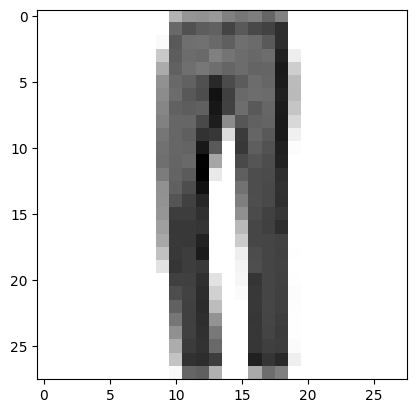

In [ ]:
plt.imshow(x_test[n_rec].reshape(28, 28), cmap=plt.cm.binary)
plt.show()

**Меняем размерность изображения и нормализуем его**

In [ ]:
x = x_test[n_rec]
x = np.expand_dims(x, axis=0)

**Запускаем распознавание**

In [ ]:
prediction = best_model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


**Печатаем результаты распознавания**

In [ ]:
prediction

array([[9.1973112e-28, 1.0000000e+00, 2.0087116e-32, 1.5073192e-28,
        9.1447465e-32, 0.0000000e+00, 1.2208028e-30, 0.0000000e+00,
        1.8131517e-29, 0.0000000e+00]], dtype=float32)

**Печатаем правильный ответ**

In [ ]:
label = np.argmax(y_test[n_rec])
print("Номер класса:", label)
print("Название класса:", classes[label])

Номер класса: 1
Название класса: брюки


## Загружаем свою картинку

In [ ]:
files.upload()

Saving tuflya.jpg to tuflya.jpg


{'tuflya.jpg': b'\x00\x00\x00\x1cftypavif\x00\x00\x00\x00avifmif1miaf\x00\x00\x00\xeameta\x00\x00\x00\x00\x00\x00\x00!hdlr\x00\x00\x00\x00\x00\x00\x00\x00pict\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0epitm\x00\x00\x00\x00\x00\x01\x00\x00\x00"iloc\x00\x00\x00\x00D@\x00\x01\x00\x01\x00\x00\x00\x00\x01\x0e\x00\x01\x00\x00\x00\x00\x00\x00\x19\x14\x00\x00\x00#iinf\x00\x00\x00\x00\x00\x01\x00\x00\x00\x15infe\x02\x00\x00\x00\x00\x01\x00\x00av01\x00\x00\x00\x00jiprp\x00\x00\x00Kipco\x00\x00\x00\x13colrnclx\x00\x01\x00\r\x00\x06\x80\x00\x00\x00\x0cav1C\x81\x01\x0c\x00\x00\x00\x00\x14ispe\x00\x00\x00\x00\x00\x00\x02r\x00\x00\x01\xa1\x00\x00\x00\x10pixi\x00\x00\x00\x00\x03\x08\x08\x08\x00\x00\x00\x17ipma\x00\x00\x00\x00\x00\x00\x00\x01\x00\x01\x04\x01\x82\x03\x04\x00\x00\x19\x1cmdat\x12\x00\n\n\x18f\'\x1d\x03\x04\x044\x1a\x102\x832\x11@\x01\x04\x10A@\xb4\x8b\xcaf\xdc\xa9\xb7\xd8E\xf1\n\x15+\xc7lR\x9e\xd9\\\xe1b\xbb\xfd\x86\x887.\x0f\xc6\xcc\x8cW\noi\xefp\xc2\x83\x03\xeb\x

Проверяем загрузку картинки

In [ ]:
!ls

dlinnaya-rubashka-ostin.com-2.jpg  rubashka.jpg  tuflya.jpg
fashion_mnist_dense.h5		   sample_data


Загружаем картинку из файла

In [ ]:
img_path = 'tuflya.jpg'
img = image.load_img(img_path, target_size=(28, 28), color_mode = "grayscale")

Показываем картинку

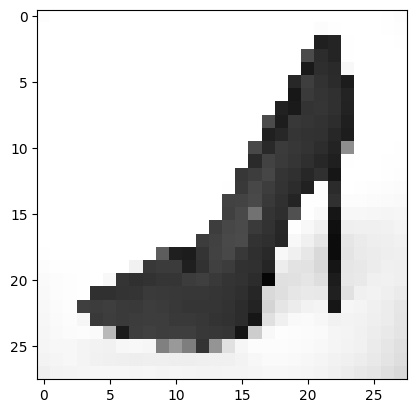

In [ ]:
plt.imshow(img.convert('RGBA'))
plt.show()

Преобразуем картинку для обработки нейронной сетью

In [ ]:
# Преобразуем картинку в массив
x = image.img_to_array(img)
# Меняем форму массива в плоский вектор
x = x.reshape(1, 784)
# Инвертируем изображение
x = 255 - x
# Нормализуем изображение
x /= 255

Запускаем распознавание

In [ ]:
prediction = best_model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


Результаты распознавания

In [ ]:
prediction

array([[1.9984188e-10, 1.0271431e-10, 4.6682471e-09, 6.7132869e-11,
        2.6533881e-11, 9.9998426e-01, 8.4228944e-09, 1.4126852e-05,
        1.6148093e-08, 1.5438594e-06]], dtype=float32)

In [ ]:
prediction = np.argmax(prediction)
print("Номер класса:", prediction)
print("Название класса:", classes[prediction])

Номер класса: 5
Название класса: туфли


## Keras Tuner

Keras Tuner - это простая среда для автоматизации настройки оптимальных гиперпараметров. Поставляется со встроенными алгоритмами случайного поиска, гиперполосной оптимизации и байесовской оптимизации.<br/>

Последовательность настройки гиперпараметров:
*   Определить модель
*   Указать гиперпараметры для настройки
*   Определить пространство поиска
*   Определить алгоритм поиска

### Определение модели
Модель, которая создается для гипертюнинга, называется *гипермоделью*.
Есть два способа построить гипермодель:
*  Используя функцию построителя модели
*  Используя подкласс [HyperModel](https://keras.io/guides/keras_tuner/getting_started/#you-can-use-a-hypermodel-subclass-instead-of-a-modelbuilding-function) API Keras Tuner
Воспользуемся первым способом. Функция построения модели использует определенные гиперпараметры для возврата скомпилированной модели.

### Гиперпараметры для настройки
Гмпермодель очень похожа на неглубокую DNN, которая была обучена ранее, за исключением того, что будут настроены четыре гиперпараметра модели:
1.   Количество скрытых слоев
2.   Количество нейронов в каждом скрытом слое
3.   Процент выпадения после каждого скрытого слоя
4.   Скорость обучения оптимизатора Adam
    
    
    

### Определение пространства поиска
Это делается путем передачи объекта HyperParameters в качестве параметра функции построения модели, которая настраивает гиперпараметры. Используем следующие параметры:
*   hp.Int() для определения области поиска по количеству скрытых слоев и количества нейронов в каждом скрытом слое. Позволяет определять минимальные и максимальные значения, а также размер шага для увеличения.
*   hp.Float() для определения области поиска параметра droput. Похоже на hp.In(), за исключением того, что принимает плавающие значения.
*   hp.Choice() для определения области поиска скорости обучения. Позволяет определять дискретные значения.
Более подробную информацию обо всех доступных методах и их использовании можно найти в [официальной документации](https://keras.io/api/keras_tuner/hyperparameters/).




In [ ]:
!pip install keras-tuner -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.5/129.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 23.7 MB/s eta 0:00:00


In [ ]:
import kerastuner as kt

Using TensorFlow backend


<ipython-input-26-5fd8096cdee5>:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


In [ ]:
def build_model(hp):
    """
    Builds model and sets up hyperparameter space to search.

    Parameters
    ----------
    hp : HyperParameter object
        Configures hyperparameters to tune.

    Returns
    -------
    model : keras model
        Compiled model with hyperparameters to tune.
    """
    # Initialize sequential API and start building model.
    model = keras.Sequential()
    # model.add(keras.layers.Flatten(input_shape=(28,28)))

    # Tune the number of hidden layers and units in each.
    # Number of hidden layers: 1 - 5
    # Number of Units: 32 - 512 with stepsize of 32
    for i in range(1, hp.Int("num_layers", 1, 5)):
        model.add(
            keras.layers.Dense(
                units=hp.Int("units_" + str(i), min_value=32, max_value=512, step=32),
                activation="relu", input_dim=784,)
            )

        # Tune dropout layer with values from 0 - 0.3 with stepsize of 0.1.
        model.add(keras.layers.Dropout(hp.Float("dropout_" + str(i), 0, 0.3, step=0.1)))

    # Add output layer.
    model.add(keras.layers.Dense(units=10, activation="softmax"))

    # Tune learning rate for Adam optimizer with values from 0.01, 0.001, or 0.0001
    hp_learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])

    # Define optimizer, loss, and metrics
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss="categorical_crossentropy",
                  # loss=keras.losses.SparseCategoricalCrossentropy(),
                  metrics=["accuracy"])

    return model

# model.compile(loss="categorical_crossentropy", optimizer="Adam", metrics=["accuracy"])

### Определение алгоритма поиска
Для поиска оптимальных гиперпараметров будем использовать алгоритм Hyperband. Это новый подход, разработанный специально для оптимизации гиперпараметров. Подробное описание алгоритма можно найти [здесь](https://jmlr.org/papers/v18/16-558.html).
Основная идея алгоритма: Hyperband использует сетку в стиле спортивного чемпионата и начинает со случайного выбора большого количества моделей со случайными перестановками гиперпараметров из области поиска. Каждая модель обучается в течение нескольких эпох, затем наиболее эффективная половина моделей переходит в следующий раунд.<br/>
Чтобы создать экземпляр тюнера, нужно определить следующие гиперпараметры:
*   Гипермодель (функция построителя моделей).
*   Цель - направление поиска (минимальное или максимальное), автоматически определяется для встроенных метрик, для пользовательских метрик можно использовать kerastuner.Objective.
*   Factor и max_epochs используются для расчета количества моделей путем взятия логарифмического базового фактора max_epochs + 1. Это число округляется до ближайшего целого числа.
*   Итерации Hyperband используются для управления ресурсами. Гиперполосные итерации - это количество повторений по всему алгоритму поиска.
*   Каталог сохраняет журналы и контрольные точки для каждого пробного запуска во время поиска по гиперпараметрам, что позволяет продолжить поиск с того места, где остановились в последний раз. Данную опцию можно отключить, установив дополнительный гиперпараметр «overwrite» = True.
*   Project_name используется для отличия от других запусков и является подкаталогом в каталоге.<br/>
Со списком всех доступных параметров можно ознакомиться в [документации](https://keras.io/api/keras_tuner/tuners/hyperband/).






In [ ]:
# Instantiate the tuner
tuner = kt.Hyperband(build_model,
                     objective="val_accuracy",
                     max_epochs=100,
                     factor=3,
                     hyperband_iterations=10,
                     directory="kt_dir",
                     project_name="kt_hyperband")

Сводка пространства поиска

In [ ]:
tuner.search_space_summary()

Search space summary
Default search space size: 2
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 5, 'step': 1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


Установим обратные вызовы с ранней остановкой, чтобы прервать обучение, если показатели модели не улучшаются.

In [ ]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20)

# Запускаем поиск
NUM_EPOCHS = 100
tuner.search(x_train, y_train, epochs=NUM_EPOCHS, validation_split=0.2, callbacks=[stop_early], verbose=1)

Trial 142 Complete [00h 02m 12s]
val_accuracy: 0.8865833282470703

Best val_accuracy So Far: 0.8933333158493042
Total elapsed time: 01h 22m 26s

Search: Running Trial #143

Value             |Best Value So Far |Hyperparameter
5                 |5                 |num_layers
0.001             |0.001             |learning_rate
416               |416               |units_1
0.1               |0.1               |dropout_1
448               |448               |units_2
0                 |0                 |dropout_2
384               |384               |units_3
0.1               |0.1               |dropout_3
224               |224               |units_4
0                 |0                 |dropout_4
34                |12                |tuner/epochs
12                |4                 |tuner/initial_epoch
4                 |4                 |tuner/bracket
3                 |2                 |tuner/round
0138              |0114              |tuner/trial_id

Epoch 13/34
1500/1500 [=========

После завершения поиска можно получить лучшие гиперпараметры и переобучить модель.

In [ ]:
# Get the optimal hyperparameters from the results
best_hps=tuner.get_best_hyperparameters()[0]

# Build model
h_model = tuner.hypermodel.build(best_hps)

# Train the hypertuned model
h_model.fit(x_train, y_train, epochs=NUM_EPOCHS, validation_split=0.2, callbacks=[stop_early], verbose=1)

Оценить гипертонастроенную модель на тестовом наборе.